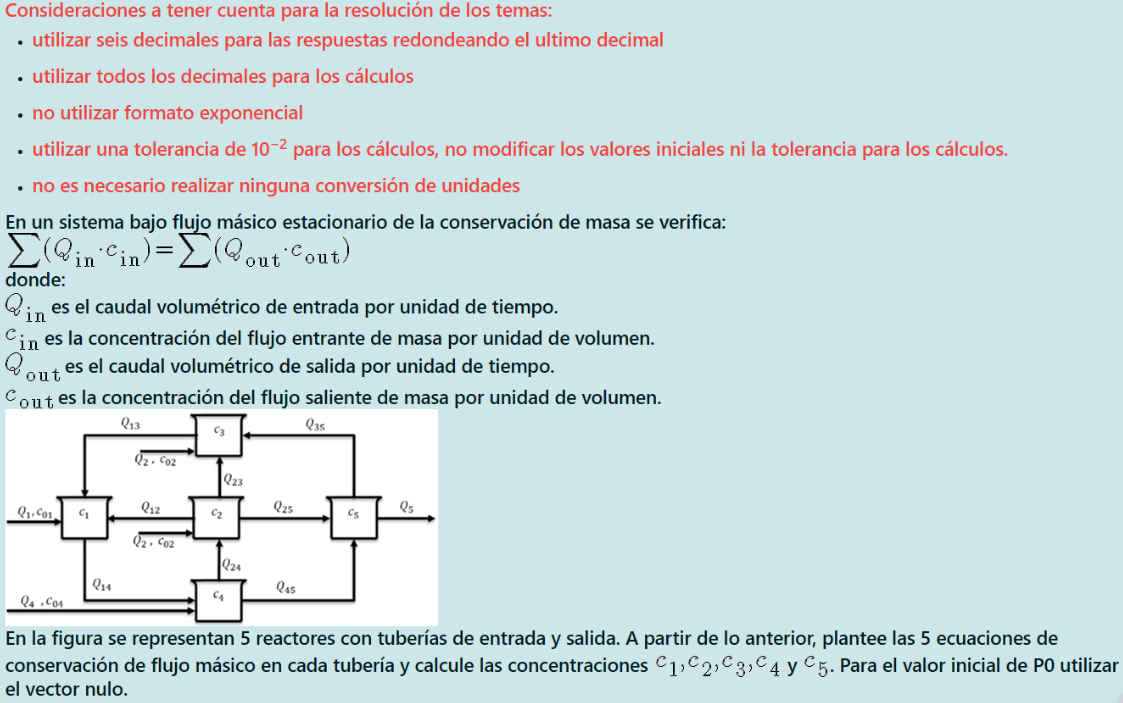

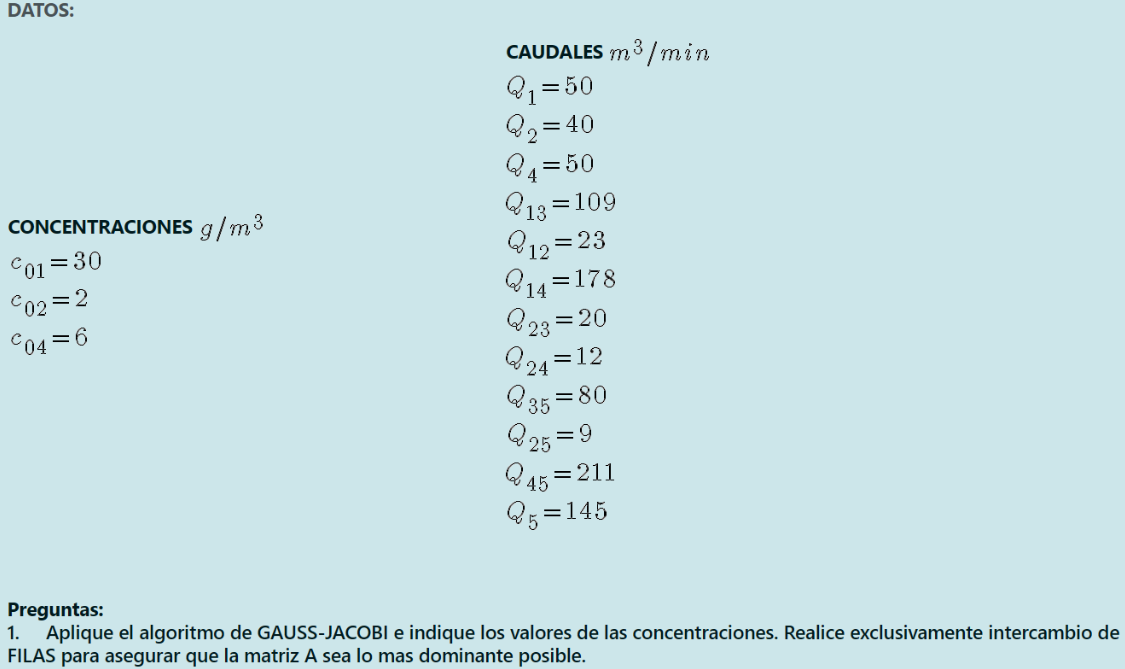

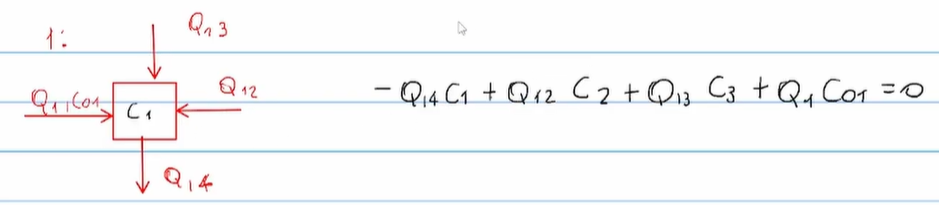

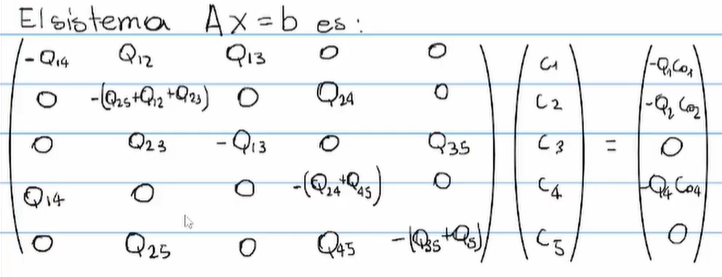

In [5]:
# Ecuaciones:
# c1: - Q14*c1 + Q12*c2 + Q13*c3 = - Q1*c01
# c2: - (Q12 + Q23 + Q25)*c2 + Q24*c4 = - Q2*c02
# c3: Q23*c2 - Q13*c3 + Q35*c5 = - Q2*c02
# c4: Q14*c1 - (Q24 + Q45)*c4 = - Q4*c04
# c5: Q25*c2 + Q45*c4 - (Q35 - Q5)*c5 = 0

import numpy as np

# CAUDALES m^3/min
Q1=50
Q2=40
Q4=50
Q12=23
Q13=109
Q14=178
Q23=20
Q24=12
Q25=9
Q35=80
Q45=211
Q5=145

# CONCENTRACIONES g/m^3
c01=30
c02=2
c04=6

A=np.array([[-Q14, Q12, Q13, 0, 0],
            [0, -(Q12 + Q23 + Q25), 0, Q24, 0],
            [0, Q23, -Q13, Q35, 0],
            [Q14, 0, 0, -(Q24 + Q45), 0],
            [0, Q25, 0, Q45, -(Q35 + Q5)]])

B=np.array([[-Q1*c01],
            [-Q2*c02],
            [-Q2*c02],
            [-Q4*c04],
            [0]])

print(A)
print(B)

# Se comprueba que sea diagonalmente superior

[[-178   23  109    0    0]
 [   0  -52    0   12    0]
 [   0   20 -109   80    0]
 [ 178    0    0 -223    0]
 [   0    9    0  211 -225]]
[[-1500]
 [  -80]
 [  -80]
 [ -300]
 [    0]]


In [12]:
import numpy as np
import os
os.system('cls')
np.set_printoptions(suppress=True)

A = np.array([
    [-178,   23,  109,    0,    0],
    [   0,  -52,    0,   12,    0],
    [   0,   20, -109,   80,    0],
    [ 178,    0,    0, -223,    0],
    [   0,    9,    0,  211, -225]], dtype=float)

B = np.array([
    [-1500],
    [-80],
    [-80],
    [-300],
    [0]], dtype=float)

n=len(B)
P=np.zeros(n, dtype=float)
tol=1e-2
m=100

X=np.array([[0],[0],[0],[0],[0]],dtype=float)
# Rutina 3 - Gauss-Seidel
for i in range(m):
    for j in range(n):          
        X[j] = (B[j] - A[j, np.delete(np.arange(n), j) ].dot(X[np.delete(np.arange(n), j) ])) / A[j, j]
    err = np.linalg.norm(X - P)
    normX = np.linalg.norm(X)
    relerr = err / normX
    if tol > err or tol > relerr:
        break
    else:
        P = X.copy()

print(X)
print(err, relerr)
print(i+1)


[[16.44069318]
 [ 4.87331395]
 [12.23438943]
 [14.468356  ]
 [13.76303529]]
0.17600354780297048 0.0060637534799051086
10
